# CFPB - Customer Complaint Analysis

The **Consumer Financial Protection Bureau** (CFPB) is a U.S. government regulatory agency established to protect consumers in the financial marketplace. The agency operates a centralized system where consumers can submit complaints regarding financial institutions, prompting the company to review and respond. 
According to the official 2025 statistics: *the CFPB received around $6.63M$ consumer complaints via its registered portal, toll-free number, postal mail, referrals from other regulatory bodies, etc., and routed around $5.98M$ complaints to over $4K$ companies for review with an expected response TAT of ${<}15days$.*\
These archived reports contain detailed EDA breakdown: [[annual-report_2025](https://www.consumerfinance.gov/data-research/research-reports/2025-consumer-response-annual-report/)].[[annual-report_2024](https://www.consumerfinance.gov/data-research/research-reports/2024-consumer-response-annual-report/)].[[annual-report_2023](https://www.consumerfinance.gov/data-research/research-reports/consumer-response-annual-report-2023/)].[[annual-report_2022](https://www.consumerfinance.gov/data-research/research-reports/2022-consumer-response-annual-report/)].[[annual-report_2021](https://www.consumerfinance.gov/data-research/research-reports/2021-consumer-response-annual-report/)]\
The portal states: <span style='font-family:Courier New, monospace; font-style:italic;'>"Complaint narratives are consumers’ descriptions of their experiences in their own words"</span>; the CFPB only performs PII masking before uploading the narratives to the database. Consider the CFPB's description of the data collection process: <span style='font-family:Courier New, monospace; font-style:italic;'>"The Consumer Complaint Database shows the consumer's original products, sub-products, issues, and sub-issues selections consistent with the options available on the form at the time the consumer submitted the complaint"</span>. i.e., the data annotation is performed by the individual customers themselves, not something directly actionable by CFPB staff.
<div style='border: 2px solid black; padding: 15px; font-size: 1.2em; font-weight: bold; border-radius: 5px; width: max-content;'>
    It is more sensible to spend effort understanding the themes and patterns within tagged complaints than trying to automatically assign those tags.
</div>



# Table of Contents

- [Extracting only the relevant data](#extracting-only-the-relevant-data)
- [Let's count...](#lets-count)
- [Your biggest competetion is you!](#your-biggest-competetion-is-you)
- [Can you read between the lines?](#can-you-read-between-the-lines)
- [After all, birds of a feather flock together] https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_hierarchy.html
- [The odd one out] https://maartengr.github.io/BERTopic/getting_started/outlier_reduction/outlier_reduction.html
- [A stitch in time saves nine] https://maartengr.github.io/BERTopic/getting_started/topicsovertime/topicsovertime.html
- [One step ahead of time]


## Extracting only the relevant data
As of 21-June-2026, the CFPB [Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/search/?dateRange=All&date_received_max=2026-06-20&date_received_min=2011-12-01&page=1&searchField=all&size=25&sort=created_date_desc&tab=List) hosted around $16M$ records dating back to 2011. Instead of downloading the entire database dump, we pulled a 6-month window of data via the CFPB API after accounting for the portal's 15-day publishing lag. Only records with written narratives were retrieved, thereby excluding at the server level the $96\%$ of records within that timeframe that contained only category tags and blank text.\
Although the database is a collection of self-reported experiences rather than a statistical sample of marketplace consumers, companies still use this complaint data to identify potential weaknesses in specific products or services and to make future improvements. 

In [16]:
%load_ext autoreload 
%autoreload 2
from pathlib import Path
import numpy as np, pandas as pd
import warnings ; warnings.simplefilter('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'retina'

Source_dir = list(Path('./data').glob("data_*.csv"))
Path('./temp').mkdir(exist_ok=True)

Head = pd.read_csv(Source_dir[0],header=0,index_col=False,dtype='string',nrows=5).set_axis(range(1, 6),axis=0) ; Head

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
1,2025-12-01T01:57:40.000Z,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,I disputed these accounts on multiple occasion...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,WI,53218,<NA>,Web,2025-12-01T01:58:03.000Z,Closed with explanation,Yes,17604356
2,2025-12-01T01:57:40.000Z,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,I disputed these accounts on multiple occasion...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",WI,53218,<NA>,Web,2025-12-01T01:58:04.000Z,Closed with non-monetary relief,Yes,17597979
3,2025-12-01T00:06:58.000Z,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,I have been a victim of Identity theft. my inf...,<NA>,"EQUIFAX, INC.",CA,90815,<NA>,Web,2025-12-01T00:07:23.000Z,Closed with explanation,Yes,17604976
4,2025-12-01T03:43:39.000Z,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,In accordance with the Fair Credit Reporting a...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NJ,07112,<NA>,Web,2025-12-01T03:44:03.000Z,Closed with explanation,Yes,17598398
5,2025-12-01T03:53:53.000Z,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,I recently review a copy of my credit report a...,<NA>,"EQUIFAX, INC.",CA,92026,<NA>,Web,2025-12-01T04:09:58.000Z,Closed with non-monetary relief,Yes,17624194


In [13]:
from my_scripts import preprocessing

Data_Narrative,MASK_Names = preprocessing.clean_text(Source_dir)
print(f'''#n_rows: {Data_Narrative.shape[0]}\nmin_date: {Data_Narrative["DateReceived"].min()}\nmax_date: {Data_Narrative["DateReceived"].max()} ''')
Data_Narrative.info()

HasNA('Product','Narrative'):0
#n_rows: 133424
min_date: 2025-12-01
max_date: 2026-05-31 
<class 'pandas.DataFrame'>
RangeIndex: 133424 entries, 0 to 133423
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype    
---  ------        --------------   -----    
 0   DateReceived  133424 non-null  period[D]
 1   Product       133424 non-null  category 
 2   SubProduct    133424 non-null  category 
 3   Issue         133424 non-null  category 
 4   SubIssue      121766 non-null  category 
 5   Narrative     133424 non-null  string   
 6   Company       133424 non-null  category 
 7   Response      133424 non-null  category 
 8   ComplaintID   133424 non-null  string   
dtypes: category(6), period[D](1), string(2)
memory usage: 158.9 MB


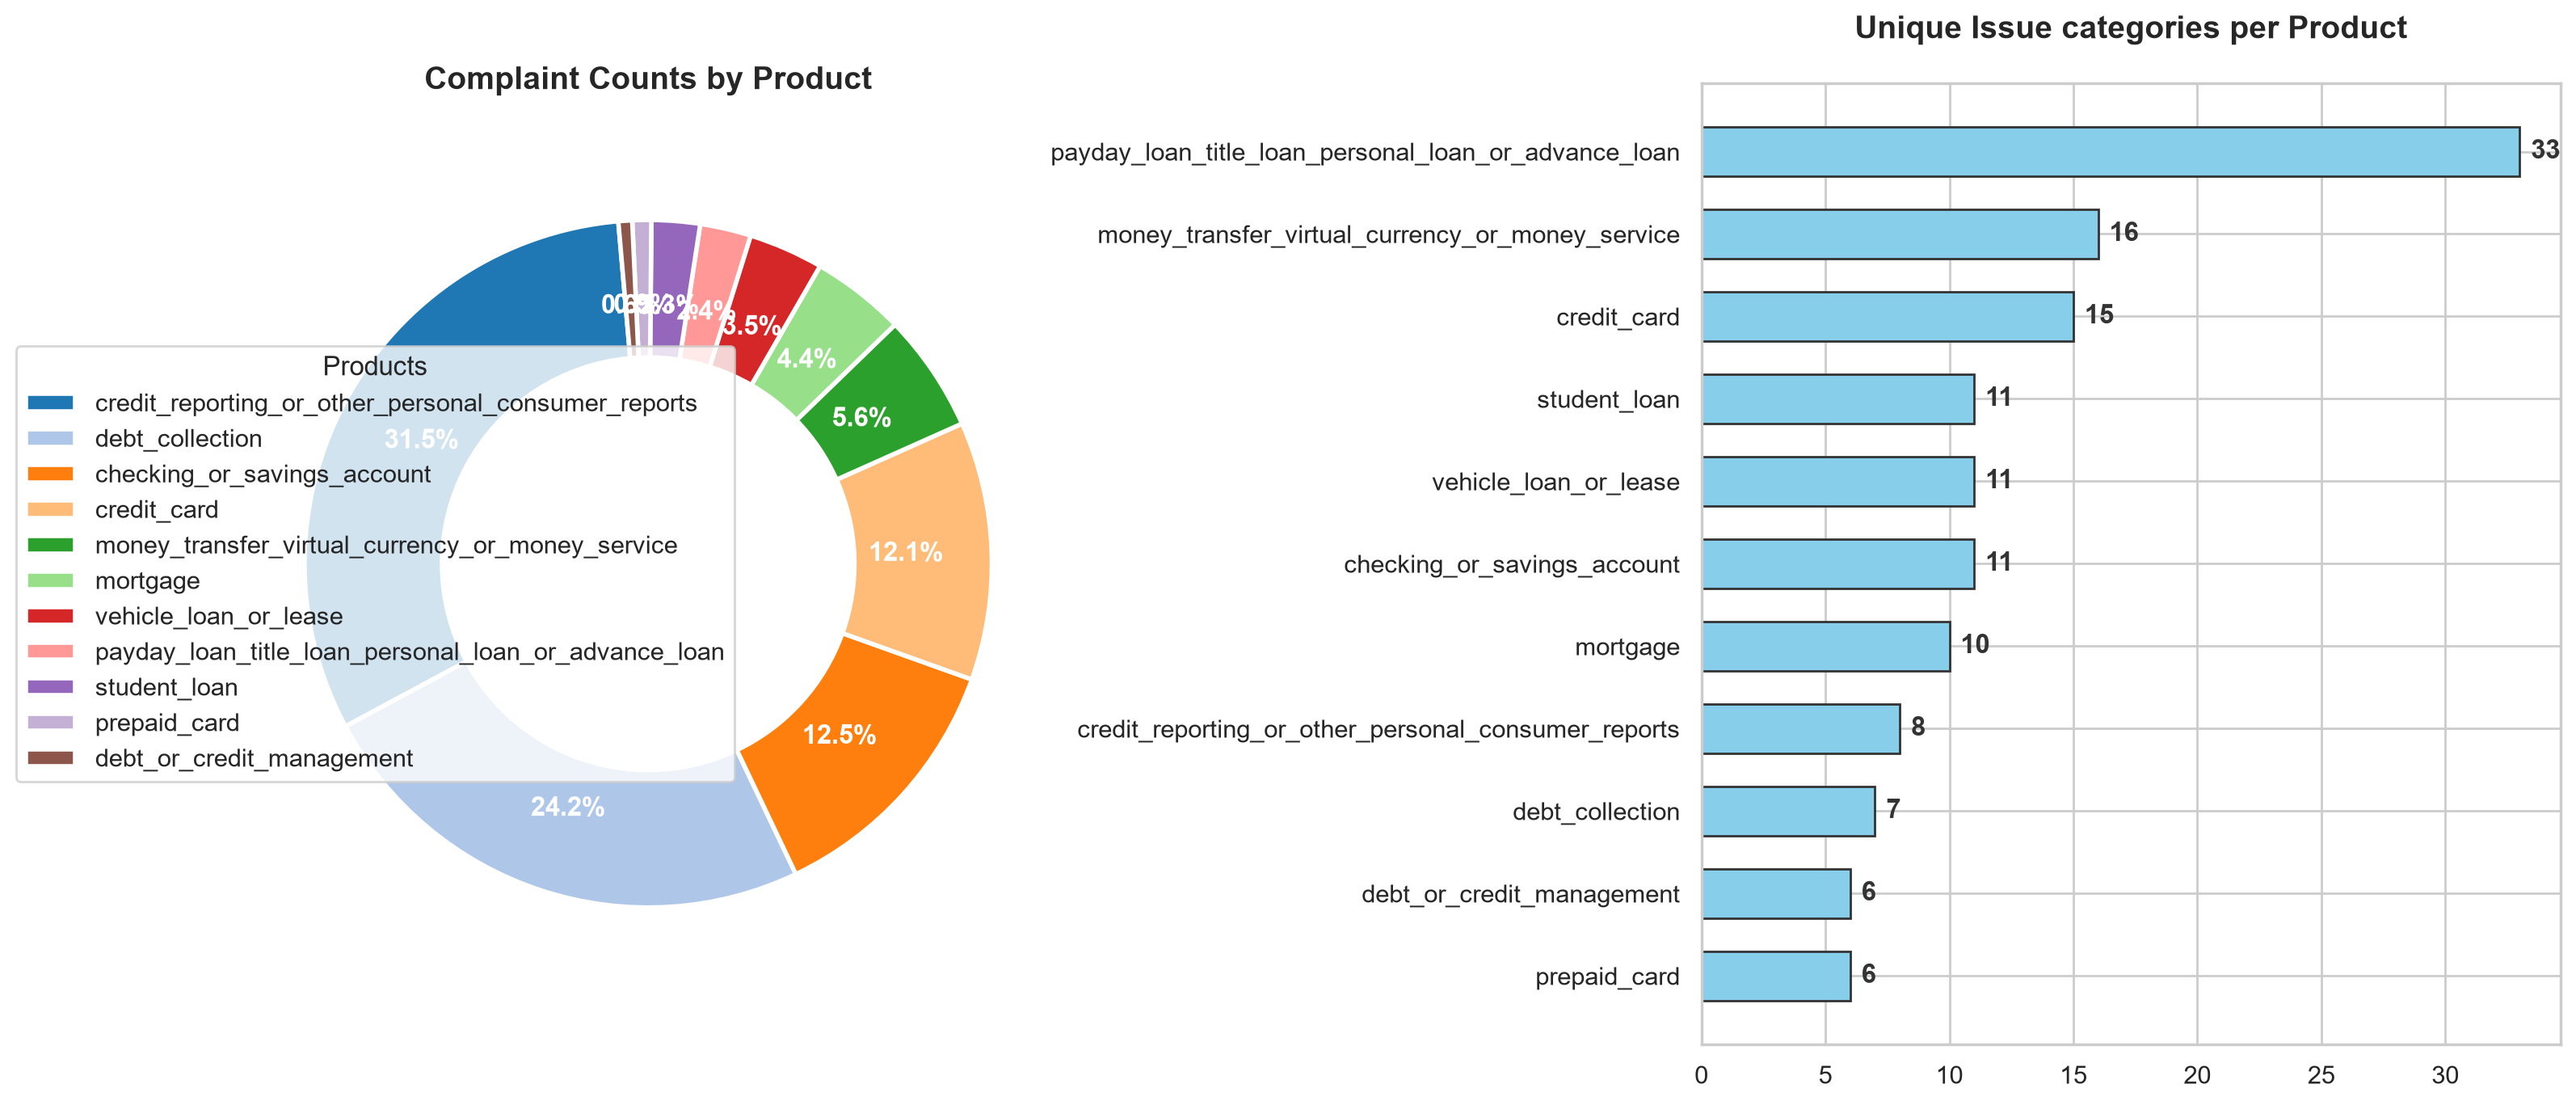

In [3]:
Summary = (
    pd.pivot_table(Data_Narrative,index="Product",aggfunc={"SubProduct":'nunique',"Narrative":'count',"Issue":'nunique'},sort=False).sort_values("Narrative",ascending=False),
    pd.pivot_table(Data_Narrative,index="Issue",aggfunc={"SubIssue":'nunique',"Narrative":'count'},sort=False).sort_values("Narrative",ascending=False)
)
sns.set_theme(style='whitegrid') 
fig,axes = plt.subplots(1,2,figsize=(16,7))

# --- PLOT 1: PIE CHART ---
df_pie = Summary[0]["Narrative"].sort_values(ascending=False)
colors = sns.color_palette('tab20',len(df_pie))
wedges,texts,autotexts = axes[0].pie(
    Summary[0]["Narrative"],
    autopct='%1.1f%%',
    startangle=95,
    colors=colors,
    textprops=dict(color='w',weight='bold'),
    pctdistance=0.75,
    wedgeprops=dict(width=0.4,edgecolor='w',linewidth=2) 
)
axes[0].legend(
    wedges, Summary[0].index,
    title='Products',
    loc='center left',
    bbox_to_anchor=(-0.25,0.5),
    frameon=True
)
axes[0].set_title('Complaint Counts by Product',fontsize=14,pad=20,weight='bold')
# --- ---
# --- PLOT 2: HORIZONTAL BAR CHART ---
df_bars = Summary[0]["Issue"].sort_values(ascending=True)
bars = axes[1].barh(
    df_bars.index, 
    df_bars, 
    color='skyblue', 
    edgecolor='#333333',
    linewidth=1,
    height=0.6
)
axes[1].set_title('Unique Issue categories per Product',fontsize=14,pad=20,weight='bold')
axes[1].set_ylabel('',fontsize=11) 
axes[1].bar_label(bars,padding=5,weight='bold',color='#333333')
# --- ---

plt.tight_layout()
plt.show()

<div style='border: 2px solid black; padding: 15px; font-size: 1.2em; font-weight: bold; border-radius: 5px; width: max-content;'>
    With 89 distinct options in total, the current submission dropdown contains far too many issue labels for easy human comprehension.
     
    Eliminating this layer and instead using NLP to automatically identify the underlying theme of each complaint 
    could significantly improve the process, 
    while retaining the existing 11 product labels as the baseline categorization.
</div>

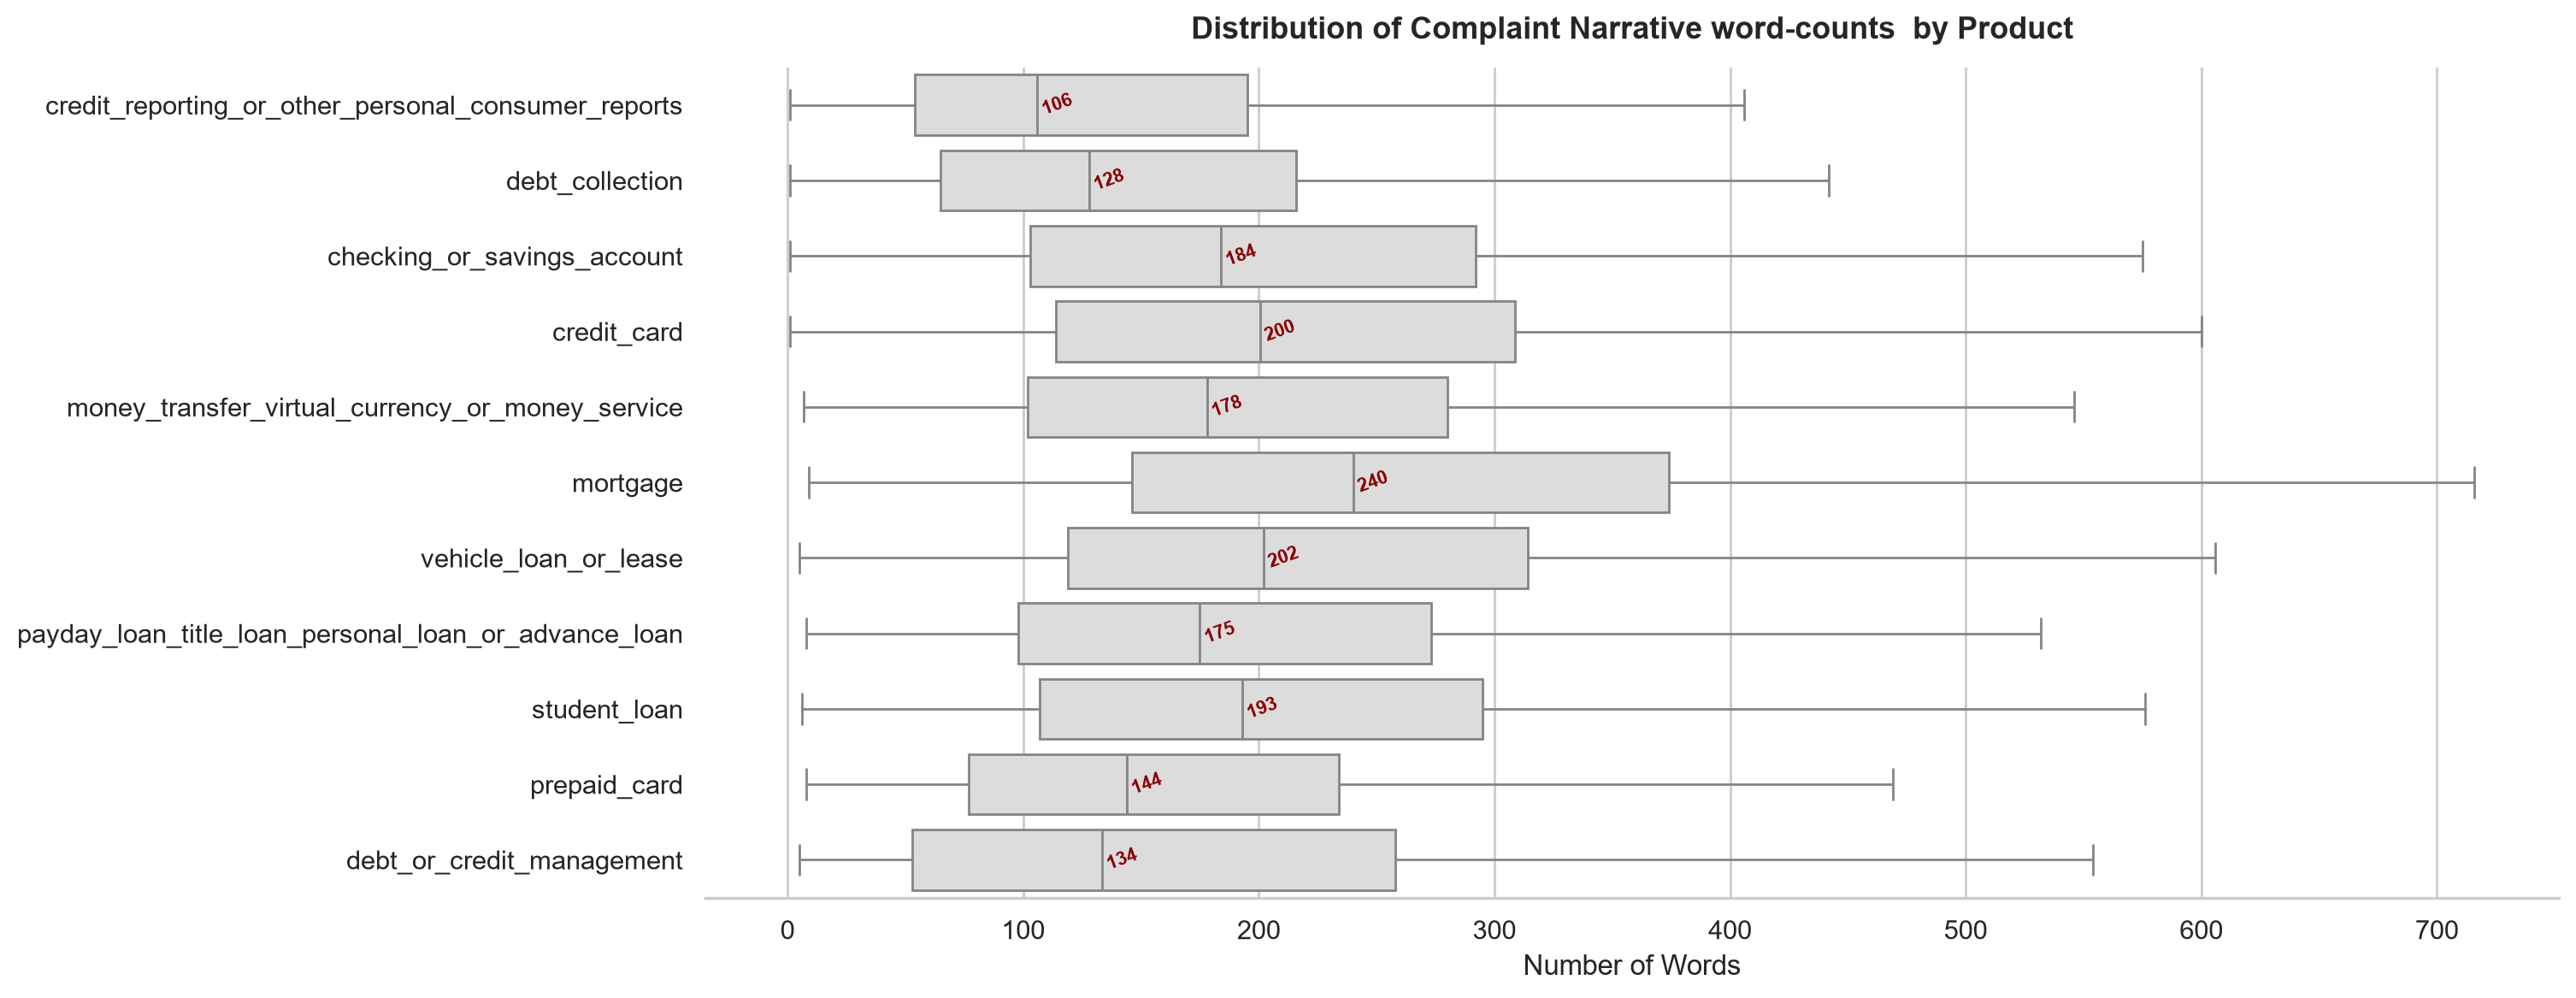

In [4]:
df_wordcount = Data_Narrative.assign(WordCount=Data_Narrative["Narrative"].str.split().str.len())[["Product","WordCount"]].sort_values("WordCount",ascending=False)
wordcount_medians =pd.pivot_table(df_wordcount,index="Product",aggfunc={"WordCount":'median'},sort=False).reindex(index=df_pie.index)
sns.set_theme(style='whitegrid') 
plt.figure(figsize=(15,6))
ax = sns.boxplot(
    data=df_wordcount,
    x="WordCount",y="Product",order=wordcount_medians.index,
    showfliers=False,
    color='gainsboro',linewidth=1
)
for y,median in enumerate(wordcount_medians["WordCount"]):
    ax.text(
        median+1,y,
        f'{median:.0f}',
        va='center',ha='left',fontsize=8,color='darkred',fontweight='bold',rotation=20
    )
ax.set_title(
    'Distribution of Complaint Narrative word-counts  by Product',
    fontsize=13,weight='bold',pad=12,
)
ax.set_xlabel('Number of Words')
ax.set_ylabel('')
sns.despine(ax=ax,top=True,right=True,bottom=False,left=True)

plt.tight_layout()
plt.show()

## Let's count... 

Let us start with a simple idea: identify characteristic keywords—words that occur frequently within a particular complaint class but are relatively uncommon across other complaint classes. This can be achieved using [`class-based TF-IDF`](https://www.maartengrootendorst.com/blog/ctfidf/), where all documents belonging to the same class are concatenated into a single corpus and **TF-IDF** scores are computed at the class level to identify the most representative keywords for each class.

In [ ]:
from my_scripts import ClassKeywordExtractor,miscllaneous
from spacy.parts_of_speech import IDS

"""
Clean_Narrative = miscllaneous.spaCy_cleaner(
    Data_Narrative["Narrative"],
    stop_words=MASK_Names,
    exclude_pos=IDS.keys()-{'NOUN','PROPN','ADJ','VERB','NUM'},
    # Bag-of-Words type methods works the best when the text is properly normalized
    # HEURISTIC : The gist of a complaint is majorly capured in Noun/Adj/Verb and occasionally in Numbers 
    **{"n_process":8,"batch_size":1000}
)
pd.Series(Clean_Narrative,name='Clean_Narrative').to_csv('./temp/Clean_Narrative.csv',index=False,header=True)
"""
Clean_Narrative = pd.read_csv('./temp/Clean_Narrative.csv',header=0,index_col=False,dtype='string').squeeze()
cTfIdf = ClassKeywordExtractor.Top_n_cTFIDF(ngram_range=(1,1))
Top_Keywords_1 = cTfIdf.fit_transform(Clean_Narrative,Data_Narrative["Product"])
cTfIdf2 = ClassKeywordExtractor.Top_n_cTFIDF(ngram_range=(2,4))
Top_Keywords_2to4 = cTfIdf2.fit_transform(Clean_Narrative,Data_Narrative["Product"])

In [11]:
Top_Keywords_1.reindex(index=df_pie.index)

,Top_1,Top_2,Top_3,Top_4,Top_5,Top_6,Top_7,Top_8,Top_9,Top_10
Product,,,,,,,,,,
credit_reporting_or_other_personal_consumer_reports,marcus,hsa,schwab,chexsystems,dispense,optum,axos,sofis,openbank,promo
debt_collection,barclays,bilt,barclay,citis,1026.13,macys,sapphire,fnbo,concora,elan
checking_or_savings_account,conviction,antedate,559.72,fccpa,each,605,physically,challenged,501.203,civ
credit_card,1618d,1006.34,jefferson,midland,lvnv,credence,resurgent,caine,weiner,iq
money_transfer_virtual_currency_or_money_service,shellpoint,fha,sps,phh,newrez,cooper,selene,pennymac,mr.,pmi
mortgage,westlake,bridgecrest,exeter,kia,hyundai,honda,lienholder,repo,carmax,gm
vehicle_loan_or_lease,americor,wentworth,jg,beyond,cordoba,saint,telemarketing,deuda,clearone,subparagraph
payday_loan_title_loan_personal_loan_or_advance_loan,installer,titlemax,onemain,affirms,uprova,opploans,sezzle,usury,lendingpoint,koalafi
student_loan,netspend,vanilla,way2go,blackhawk,incomm,edd,conduent,comerica,reliacard,onbe


In [12]:
Top_Keywords_2to4.reindex(index=df_pie.index)

,Top_1,Top_2,Top_3,Top_4,Top_5,Top_6,Top_7,Top_8,Top_9,Top_10
Product,,,,,,,,,,
credit_reporting_or_other_personal_consumer_reports,ally bank,atm withdrawal,mobile deposit,provide provisional,provide provisional credit,business check account,unauthorized debit card transaction,bank branch,promotional bonus,regulation cc
debt_collection,apple card,promotional balance,paypal credit,comenity bank,reward point,replacement card,credit card issue,capital one credit card,promotional financing,call citi
checking_or_savings_account,date open balance,number date open balance,impair efficiency,impair efficiency banking,impair efficiency banking system,efficiency banking,efficiency banking system,system violation,banking system violation,act 15 u.s.
credit_card,report credit account,collector report,debt collector report,collector report credit,right fair credit act,report credit file right,debt collector report credit,consumer report violation,investigation consumer report violation,investigation consumer report
money_transfer_virtual_currency_or_money_service,rocket mortgage,freedom mortgage,mortgage servicing,mortgage servicer,escrow analysis,mr. cooper,homeowner insurance,escrow shortage,mortgage assistance,foreclosure activity
mortgage,ally financial,auto finance,westlake financial,retail installment,santander consumer,auto loan account,exeter finance,consumer usa,santander consumer usa,gm financial
vehicle_loan_or_lease,national debt,national debt relief,enrol debt,jg wentworth,beyond finance,debt settlement program,settlement program,item block remove,need item block,need item block remove
payday_loan_title_loan_personal_loan_or_advance_loan,solar system,solar loan,solar servicing,dispute affirm,onemain financial,use affirm,payday loan,affirm deny,loan structure,solar servicing llc
student_loan,prepaid card,replacement card,direct express,money network,american express gift,express gift,american express gift card,express gift card,activate card,vanilla gift


Here, we list the top 10 characteristic keywords for each complaint class, separately for unigrams and for 2- and 3-grams. The key observations are as follows:

- As a purely frequency-based approach, c-TF-IDF tends to rank prominent company names within a particular product category (e.g., Barclays, Americor, Coinbase, and Western Union) among the top keywords, particularly for unigrams. Since the dataset already contains a dedicated Company Name field, these keywords provide little additional information.
- Although complaint-specific phrases such as 'edd', 'atm withdrawal', 'private student loan', 'auto loan account', 'escrow analysis', and 'unauthorized debit card transaction' are successfully identified, **n-gram fragmentation**—resulting in incomplete phrases such as 'impair efficiency', 'use affirm', and 'affirm deny'—highlights the inability of a frequency-based model to capture the semantic meaning of multi-word expressions.
Some extracted keywords are **not self-explanatory** without their surrounding context. For example, '559.72' refers to a provision of the FCCPA that protects consumers from deceptive threats, but the keyword alone does not convey this meaning.

Considering these limitations, we treat c-TF-IDF as a baseline and next proceed to embedding-based approaches, which can better capture semantic relationships between words and phrases.

## Your biggest competetion is you!

Unlike regression or classification, where model performance can be evaluated against a known ground truth, unsupervised learning lacks an objective target for validation. To assess whether the discovered patterns reflect genuine structure rather than random noise, we partition the dataset into two equal halves and apply the same methodology independently to each subset. We then compare the resulting outputs to evaluate their consistency. This approach, commonly referred to as [**stability analysis**](https://wires.onlinelibrary.wiley.com/doi/pdf/10.1002/wics.1575) (or, more specifically, split-half stability analysis), is based on the premise that patterns reproduced across both subsets are more likely to represent true signal.

## Can you read between the lines?

Here, instead of reading one, two, or three words at a time, we rely on a representative **dense embedding vector for each complaint narrative**, enabling numerical operations based on the semantic similarity between narratives. The end goal remains the same: to describe, in a few words, what the complaints are all about.\
To achieve this, we use [`BERTopic`](https://maartengr.github.io/BERTopic/algorithm/algorithm.html), an embedding-based topic modeling framework. Under the hood, `BERTopic` performs the following steps:
<ol type="i"> 
    <li>Create a sentence embedding for each complaint narrative.</li> 
    <li>Reduce the high-dimensional embedding vectors to a more manageable dimension.</li> 
    <li>Cluster the complaint narratives based on their reduced embeddings.</li> 
    <li>Extract representative keywords to describe each cluster.</li> 
</ol>

All of this complexity is hidden behind a plug-and-play interface, allowing us to perform topic modeling with a single '.fit_transform()' call.

Previous studies have extensively explored topic modeling on CFPB complaint narratives using classical LDA method [[1](https://arxiv.org/pdf/1807.07468)]. In this work, we adopt **BERTopic** because its default pipeline automatically infers the number of topics from the data (at the clustering stage, to be specific), rather than requiring the number of topics to be specified as a hyperparameter. Furthermore, instead of performing topic discovery in a completely unsupervised setting using the text narratives, as in many previous analyses [[2](https://www.researchgate.net/profile/Bharath-Bolla-3/publication/362095511_Topic_Modelling_on_Consumer_Financial_Protection_Bureau_Data_An_Approach_Using_BERT_Based_Embeddings/links/63de2b56c97bd76a8266789a/Topic-Modelling-on-Consumer-Financial-Protection-Bureau-Data-An-Approach-Using-BERT-Based-Embeddings.pdf)], we leverage the existing CFPB issue labels within a [**Semi-supervised Topic Modeling framework**](https://maartengr.github.io/BERTopic/getting_started/semisupervised/semisupervised.html). These labels provide weak supervision (at the dimensionality reduction stage, to be specific) that gives the topic discovery process a head start while still allowing the model to discover latent semantic topics, without requiring manually curated seed words (e.g., in Seeded LDA). Later, we utilize the built-in [**Topics per Class framework**](https://maartengr.github.io/BERTopic/getting_started/topicsperclass/topicsperclass.html) to examine how the discovered themes intersect with our existing product labels.